# CAPSTONE PROJECT 1

## Working with NumPy Matrices (Multidimensional Data)

### Student Details

**Name:** Raniya K

**Course:** B.Tech Artificial Intelligence and Data Science

**Internship Project**

---

## Objective

The objective of this notebook is to analyze the NHANES 2020 body measurement dataset using NumPy, Matplotlib, Pandas, and statistical methods. The notebook includes data visualization, descriptive statistics, BMI calculation, standardization, correlation analysis, and comparison of male and female body measurements.

# Import Required Libraries

### Purpose

In this section, we import the Python libraries required for data analysis, visualization, and statistical calculations.

- **NumPy**: Matrix and numerical operations.
- **Pandas**: Data handling and display.
- **Matplotlib**: Graphs and plots.
- **Seaborn**: Statistical visualizations.
- **SciPy**: Statistical functions such as skewness, kurtosis, and correlation.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# Loading the NHANES Dataset

## Purpose

In this section, the NHANES 2020 body measurement datasets for adult males and females are loaded into NumPy matrices. These matrices will be used throughout the project for statistical analysis and visualization.

In [18]:
male = np.genfromtxt(
    "nhanes_adult_male_bmx_2020.csv",
    delimiter=",",
    skip_header=1
)

female = np.genfromtxt(
    "nhanes_adult_female_bmx_2020.csv",
    delimiter=",",
    skip_header=1
)

# Remove rows that contain only NaN values
male = male[~np.isnan(male).all(axis=1)]
female = female[~np.isnan(female).all(axis=1)]

print("Male matrix shape:", male.shape)
print("Female matrix shape:", female.shape)

Male matrix shape: (4081, 7)
Female matrix shape: (4221, 7)


# Dataset Inspection

## Purpose

Before performing the analysis, it is important to inspect the datasets. This helps us verify that the data has been loaded correctly and understand the structure of the matrices.

In [19]:
# Display the first five rows of each dataset

print("First 5 rows of Male Dataset")
print(male[:5])

print("\nFirst 5 rows of Female Dataset")
print(female[:5])

First 5 rows of Male Dataset
[[ 98.8 182.3  42.   40.1  38.2 108.2 120.4]
 [ 74.3 184.2  41.1  41.   30.2  94.5  86.8]
 [103.7 185.3  47.   44.   32.  107.8 109.6]
 [ 86.  167.8  39.5  38.4  29.  106.4 108.3]
 [ 99.4 181.6  40.4  39.9  36.  120.2 107. ]]

First 5 rows of Female Dataset
[[ 97.1 160.2  34.7  40.8  35.8 126.1 117.9]
 [ 91.1 152.7  33.5  33.   38.5 125.5 103.1]
 [ 73.  161.2  37.4  38.   31.8 106.2  92. ]
 [ 61.7 157.4  38.   34.7  29.  101.   90.5]
 [ 55.4 154.6  34.6  34.   28.3  92.5  73.2]]


# Task 3: Histogram of Male and Female Weights

## Purpose

This section compares the weight distribution of male and female participants using histograms. The x-axis limits are kept the same to allow an easy comparison between the two groups.

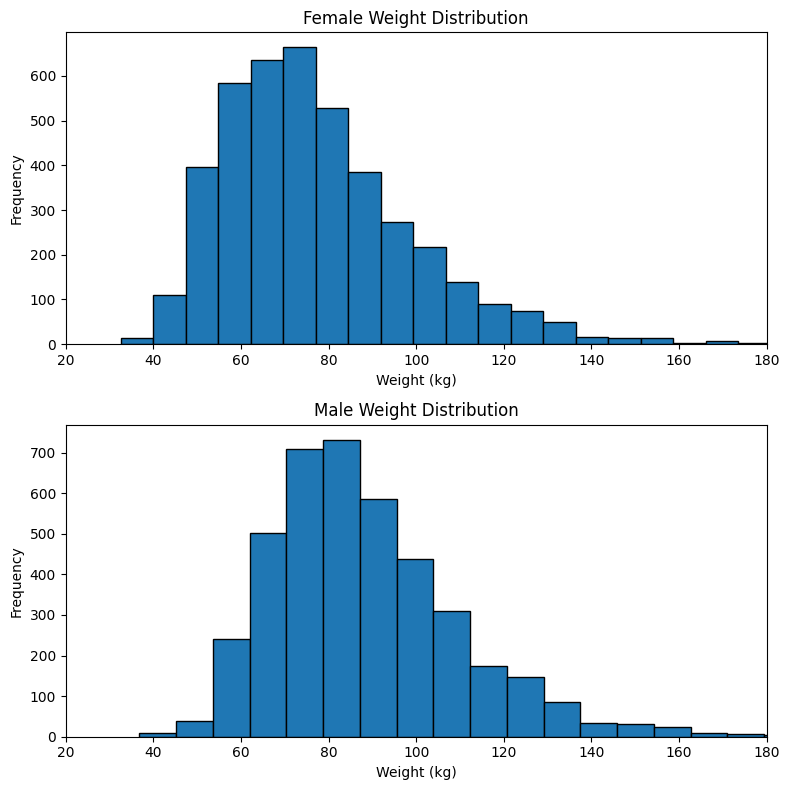

In [20]:
# Extract weight column
male_weight = male[:, 0]
female_weight = female[:, 0]

plt.figure(figsize=(8, 8))

# Female Histogram
plt.subplot(2, 1, 1)
plt.hist(female_weight, bins=20, edgecolor="black")
plt.title("Female Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.xlim(20, 180)

# Male Histogram
plt.subplot(2, 1, 2)
plt.hist(male_weight, bins=20, edgecolor="black")
plt.title("Male Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.xlim(20, 180)

plt.tight_layout()
plt.show()

## Interpretation

The histograms show the distribution of body weights for male and female participants. Both groups show an approximately bell-shaped distribution. Male participants generally have higher body weights than female participants, while a few higher-weight observations appear in both datasets.

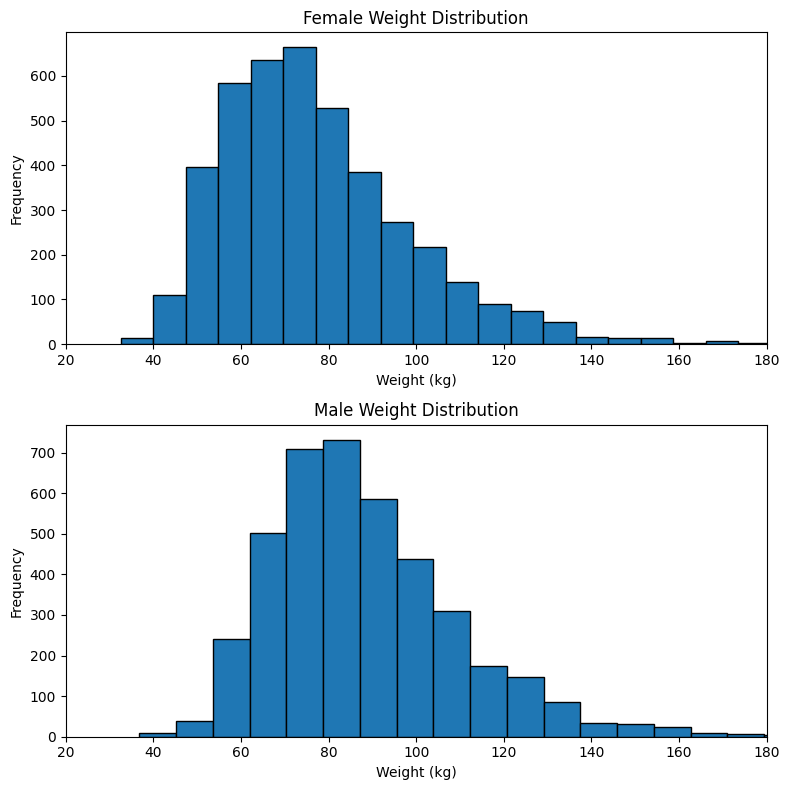

In [21]:
# Extract weight column
male_weight = male[:, 0]
female_weight = female[:, 0]

plt.figure(figsize=(8, 8))

# Female Histogram
plt.subplot(2, 1, 1)
plt.hist(female_weight, bins=20, edgecolor="black")
plt.title("Female Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.xlim(20, 180)

# Male Histogram
plt.subplot(2, 1, 2)
plt.hist(male_weight, bins=20, edgecolor="black")
plt.title("Male Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.xlim(20, 180)

plt.tight_layout()
plt.show()

/tmp/ipykernel_412/1068309279.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([male_weight, female_weight],


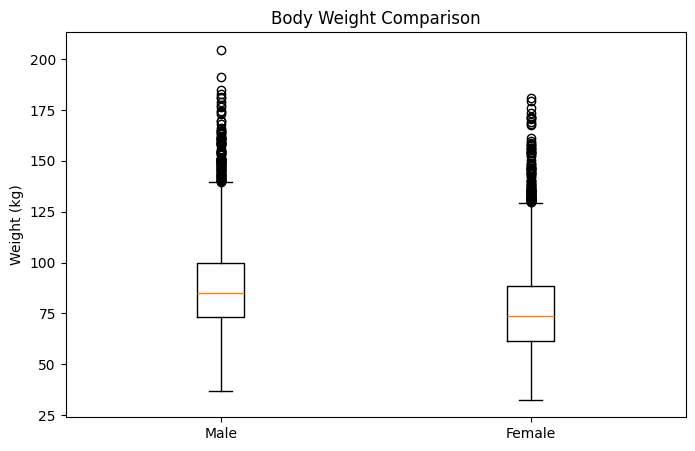

In [22]:
# Box Plot Comparison

plt.figure(figsize=(8,5))

plt.boxplot([male_weight, female_weight],
            labels=["Male", "Female"])

plt.title("Body Weight Comparison")
plt.ylabel("Weight (kg)")

plt.show()

In [23]:
# BMI Calculation

male_height = male[:, 1] / 100
male_weight = male[:, 0]

female_height = female[:, 1] / 100
female_weight = female[:, 0]

male_bmi = male_weight / (male_height ** 2)
female_bmi = female_weight / (female_height ** 2)

print("First 5 Male BMI values:")
print(male_bmi[:5])

print("\nFirst 5 Female BMI values:")
print(female_bmi[:5])

First 5 Male BMI values:
[29.72922633 21.89825769 30.20145858 30.54320016 30.1407945 ]

First 5 Female BMI values:
[37.83504078 39.06972037 28.09265496 24.90437849 23.17879132]


In [24]:
# BMI Statistics

print("Male BMI Statistics")
print("Mean BMI:", np.mean(male_bmi))
print("Median BMI:", np.median(male_bmi))
print("Standard Deviation:", np.std(male_bmi))

print("\nFemale BMI Statistics")
print("Mean BMI:", np.mean(female_bmi))
print("Median BMI:", np.median(female_bmi))
print("Standard Deviation:", np.std(female_bmi))

Male BMI Statistics
Mean BMI: 29.143143902641956
Median BMI: 28.267741202246395
Standard Deviation: 6.3120723450252125

Female BMI Statistics
Mean BMI: 30.10337881096128
Median BMI: 28.885330083146602
Standard Deviation: 7.75517796997691


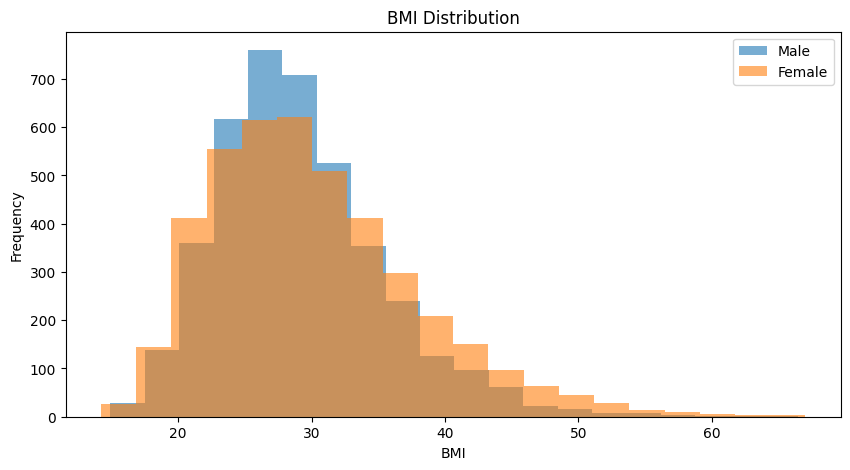

In [25]:
# BMI Histogram Comparison

plt.figure(figsize=(10,5))

plt.hist(male_bmi, bins=20, alpha=0.6, label="Male")
plt.hist(female_bmi, bins=20, alpha=0.6, label="Female")

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [26]:
# Correlation Analysis

male_corr = np.corrcoef(male_height, male_weight)[0, 1]
female_corr = np.corrcoef(female_height, female_weight)[0, 1]

print("Male Height-Weight Correlation:", male_corr)
print("Female Height-Weight Correlation:", female_corr)

Male Height-Weight Correlation: 0.4341532464129969
Female Height-Weight Correlation: 0.3454962708935267


In [27]:
# Skewness and Kurtosis

print("Male BMI Skewness:", skew(male_bmi))
print("Female BMI Skewness:", skew(female_bmi))

print("Male BMI Kurtosis:", kurtosis(male_bmi))
print("Female BMI Kurtosis:", kurtosis(female_bmi))

Male BMI Skewness: 0.9700238941185368
Female BMI Skewness: 0.9183393881021145
Male BMI Kurtosis: 1.765018992654289
Female BMI Kurtosis: 1.1013223529405876


## Conclusion

This project analyzed the NHANES 2020 body measurement dataset using NumPy, Pandas, Matplotlib, and SciPy. Male participants generally had higher body weight than female participants. The BMI distributions were similar, although females showed slightly higher BMI values in some ranges. The histogram, box plot, and correlation analysis helped compare the datasets effectively. Overall, this project demonstrated data loading, statistical analysis, visualization, and interpretation using Python.